# Evaluate MPM predictions

`model_step(batch)` returns a plain dict with `logits_mpm`, `targets_mpm`,
`valid_particle_but_masked_mask`, `acc_dict_mpm`, etc. for a *single* batch. This notebook
builds the equivalent test run output lists manually by looping over batches and appending the raw model outputs,
mirroring what the full test loop would have accumulated.


## 1. Import Required Libraries and Modules

In [1]:
import pyrootutils

pyrootutils.setup_root(__file__ if "__file__" in dir() else ".", indicator=".project-root", pythonpath=True)

import hydra
import numpy as np
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from gabbro.models.backbone_multihead import BackboneMultiHeadLightning

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## 2. Instantiate DataModule and Load a Batch

Using Hydra's `compose` API to build the same config that was used for training (so the
preprocessing / feature dict / tokenization match the checkpoint), then instantiate the
datamodule from it directly, without going through `gabbro/train.py`'s `@hydra.main`.

In [2]:
CKPT_PATH = (
    "/home/users/w/wozniak/dev/enhancing-ntp4jets/trained/omnijet-backbone-multihead-allfeat-mpm/"
    "runs/2026-08-17_11-46-48_gpu050_RetentiveUnuntrium/checkpoints/last.ckpt"
)

# Load the *resolved* config that was actually used to train this checkpoint (saved next to the
# run's checkpoints directory), instead of re-composing from the current experiment yaml. This
# matters because the experiment yaml can change over time (e.g. the `feature_dict` override in
# `example_experiment_backbone_and_head.yaml` has since been changed to the extended/all-features
# set), while this specific checkpoint was trained with a different feature_dict
# (`feature_dict_kin_massless_without_cuts.yaml`). Using the checkpoint's own resolved config
# guarantees the preprocessing/feature_dict/tokenization match what the model was actually trained on.
from pathlib import Path

resolved_cfg_path = Path(CKPT_PATH).parent.parent / "config_resolved.yaml"
cfg = OmegaConf.load(resolved_cfg_path)

print(OmegaConf.to_yaml(cfg.data.dataset_kwargs_common.feature_dict))

part_pt:
  multiply_by: 1
  subtract_by: 1.8
  func: signed_log
  inv_func: signed_exp
part_etarel:
  multiply_by: 3
part_phirel:
  multiply_by: 3
part_mass:
  clip_min_input_space: 0
part_charge: null
part_isChargedHadron: null
part_isNeutralHadron: null
part_isPhoton: null
part_isElectron: null
part_isMuon: null
part_d0val:
  func: signed_log
  inv_func: signed_exp
part_dzval:
  func: signed_log
  inv_func: signed_exp
part_d0err: null
part_dzerr: null



In [3]:
datamodule = hydra.utils.instantiate(cfg.data)
datamodule.setup(stage="test")

test_dataloader = datamodule.test_dataloader()
batch = next(iter(test_dataloader))

# move all tensors in the batch to the target device
batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
{k: (v.shape if torch.is_tensor(v) else v) for k, v in batch.items()}

Parameter seed is present in both dataset_kwargs_common (value=12345) and dataset_kwargs_train(value=42). Using the value from dataset_kwargs_train.
Parameter seed is present in both dataset_kwargs_common (value=12345) and dataset_kwargs_val(value=1). Using the value from dataset_kwargs_val.
Parameter seed_shuffle_data is present in both dataset_kwargs_common (value=12345) and dataset_kwargs_val(value=1). Using the value from dataset_kwargs_val.
Parameter seed_shuffle_data is present in both dataset_kwargs_common (value=12345) and dataset_kwargs_test(value=42). Using the value from dataset_kwargs_test.
Parameter random_seed_for_per_file_shuffling is present in both dataset_kwargs_common (value=12345) and dataset_kwargs_val(value=None). Using the value from dataset_kwargs_val.
random_seed_for_per_file_shuffling is only used if load_only_once is True.
shuffle_files is False. This means that the files list will not be shuffled.
shuffle_files is False. Will not shuffle files and continue w

{'part_features': torch.Size([250, 100, 14]),
 'part_mask': torch.Size([250, 100]),
 'jet_type_labels_one_hot': torch.Size([250, 10]),
 'jet_type_labels': torch.Size([250]),
 'jet_features': torch.Size([250, 1]),
 'part_labels': torch.Size([250, 100, 2])}

## 3. Instantiate Model and Load Checkpoint

Since the model was trained with `self.save_hyperparameters()`, `load_from_checkpoint` reconstructs
it (including `head_mpm`, `head_gen`, `head_class`) exactly as it was during training — no need to
pass in the config manually. Note: `head_mpm` will only exist (non-`None`) if the checkpoint was
trained with `loss_term_weights.mpm != 0`.

In [4]:
model = BackboneMultiHeadLightning.load_from_checkpoint(CKPT_PATH, map_location=device)
model = model.to(device)
model.eval()

print(f"head_mpm is activated: {model.head_mpm is not None}")
print(f"head_gen is activated: {model.head_gen is not None}")
print(f"head_class is activated: {model.head_class is not None}")

if model.head_mpm is None:
    raise RuntimeError(
        "This checkpoint has no trained MPM head (loss_term_weights.mpm was 0 during training). "
        "Use a checkpoint trained with mpm != 0 to evaluate MPM."
    )

NOT applying causal mask in the attention blocks. If you are using this model for an autoregressive generative task, this is probably not what you want.


head_mpm is activated: True
head_gen is activated: False
head_class is activated: False


In [5]:
print(model)

BackboneMultiHeadLightning(
  (backbone): BackboneTransformer(
    dim=128,
    part_features_input_dim=14,
    jet_features_input_dim=1,
    max_sequence_len=100,
    vocab_size=32770,
    n_registers=8,
    apply_causal_mask=False,
    (pair_embed): None,
    (input_projection): ProjectAdd(
      (embed_part): Linear(in_features=14, out_features=128, bias=True)
      (embed_jet): Linear(in_features=1, out_features=128, bias=False)
    ),
    (transformer): Transformer(
      n_blocks=8,
      dim=128,
      (blocks): ModuleList(
        (0-7): 8 x EncoderBlock(
          (attn): Residual(
            (inner_module): AttentionBlock(
              dim=128
              num_heads=8
              dropout_rate=0.1
              (pre_attn_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (post_attn_norm): None
              (attn_module): torch.nn.MultiheadAttention(
                Parameters:
                in_proj_weight=49152
                in_proj_bias=384
 

## 4. Run `model_step` Manually

This is the same function `_shared_step` calls internally, so the numbers you get here match what
`trainer.test(...)` would log — we're just calling it ourselves, one batch at a time, without a
`Trainer`.

In [6]:
with torch.no_grad():
    model_step_output = model.model_step(batch)

model_step_output.keys()

dict_keys(['loss', 'loss_mpm', 'loss_class', 'loss_gen', 'loss_mpm_weighted', 'loss_gen_weighted', 'loss_class_weighted', 'X', 'mask', 'logits_reshaped_mpm', 'targets_reshaped_mpm', 'acc_dict_mpm', 'logits_mpm', 'targets_mpm', 'valid_particle_mask', 'valid_particle_but_masked_mask', 'valid_particle_after_masking_mask', 'logits_class', 'targets_class', 'logits_gen', 'targets_gen', 'targets_gen_before_masking', 'acc_dict_gen'])

## 5. Inspect Output Dictionary Keys and Shapes

The MPM-relevant keys are: `logits_mpm` (B, T, vocab_size), `targets_mpm` (B, T),
`valid_particle_but_masked_mask` (B, T) — the mask of positions that were actually masked
during MPM corruption — and `acc_dict_mpm` (accuracy already computed by
`calc_acc_from_logits` for a fixed set of token positions).

In [7]:
for key in ["logits_mpm", "targets_mpm", "valid_particle_but_masked_mask", "loss_mpm"]:
    value = model_step_output[key]
    if torch.is_tensor(value):
        print(f"{key:35s} shape={tuple(value.shape)} dtype={value.dtype}")
    else:
        print(f"{key:35s} {value}")

print()
print("acc_dict_mpm:")
for key, value in model_step_output["acc_dict_mpm"].items():
    print(f"  {key}: {value}")

logits_mpm                          shape=(250, 100, 32770) dtype=torch.float32
targets_mpm                         shape=(250, 100) dtype=torch.int64
valid_particle_but_masked_mask      shape=(250, 100) dtype=torch.int32
loss_mpm                            shape=() dtype=torch.float32

acc_dict_mpm:
  acc_token_0: 0.9789473414421082
  acc_token_1: 0.054347824305295944
  acc_token_2: 0.030612245202064514
  acc_token_3: 0.05607476457953453
  acc_token_10: 0.030612245202064514
  acc_token_20: 0.0
  acc_token_30: 0.0
  acc_token_40: 0.02083333395421505
  acc_token_50: 0.0
  acc_token_90: nan
  acc_all_tokens: 0.039504870772361755
  frac_stop_token_included_argmax_logit: 0.0
  frac_stop_token_included_argmax_target: 0.0


### 5b. Sanity-check `acc_token_i`: sample counts and top-5 accuracy

`acc_token_0` looks suspiciously high (~98%) — that's because position 0 is always the **start
token** (a constant id, per `token_id_cfg.remove_start_token: false`), so it's trivial to predict
and not a meaningful signal. Also, `acc_token_i` for large `i` (e.g. 90) is averaged over very few
masked jets (most jets don't even have 90+ particles), so it can be noisy.

Below we check: (1) how many masked positions each `acc_token_i` is actually based on, and
(2) top-5 accuracy (is the true token among the model's 5 most likely predictions?), which is a
softer/more informative metric than exact top-1 match for a large, unordered codebook.

In [8]:
logits_mpm = model_step_output["logits_mpm"]
targets_mpm = model_step_output["targets_mpm"]
mask = model_step_output["valid_particle_but_masked_mask"]

token_indices_to_calc = [0, 1, 2, 3, 10, 20, 30, 40, 50, 90]

print(f"{'position':>10s}  {'n_masked_samples':>17s}  {'top1_acc':>9s}  {'top5_acc':>9s}")
for i in token_indices_to_calc:
    n_samples = mask[:, i].sum().item()

    if n_samples == 0:
        print(f"{i:>10d}  {n_samples:>17d}  {'n/a':>9s}  {'n/a':>9s}")
        continue

    logits_i = logits_mpm[:, i, :]
    targets_i = targets_mpm[:, i]
    mask_i = mask[:, i].bool()

    top1_correct = (torch.argmax(logits_i, dim=-1) == targets_i) & mask_i
    top1_acc = top1_correct.sum().item() / n_samples

    top5_preds = torch.topk(logits_i, k=5, dim=-1).indices  # (B, 5)
    top5_correct = (top5_preds == targets_i.unsqueeze(-1)).any(dim=-1) & mask_i
    top5_acc = top5_correct.sum().item() / n_samples

    print(f"{i:>10d}  {n_samples:>17d}  {top1_acc:>9.4f}  {top5_acc:>9.4f}")

# overall (all positions) top-5 accuracy, for comparison with acc_all_tokens (top-1)
mask_bool_all = mask.bool()
top5_preds_all = torch.topk(logits_mpm, k=5, dim=-1).indices  # (B, T, 5)
top5_correct_all = (top5_preds_all == targets_mpm.unsqueeze(-1)).any(dim=-1) & mask_bool_all
top5_acc_all = top5_correct_all.sum().item() / mask_bool_all.sum().item()
print(f"\nOverall top-5 accuracy (all masked positions): {top5_acc_all:.4f}")
print(f"(compare to acc_all_tokens / top-1: {model_step_output['acc_dict_mpm']['acc_all_tokens']:.4f})")

  position   n_masked_samples   top1_acc   top5_acc
         0                 95     0.9789     0.9789
         1                 92     0.0543     0.1522
         2                 98     0.0306     0.1531
         3                107     0.0561     0.2243
        10                 98     0.0306     0.1122
        20                 87     0.0000     0.0690
        30                 65     0.0000     0.0154
        40                 48     0.0208     0.0417
        50                 17     0.0000     0.0588
        90                  0        n/a        n/a

Overall top-5 accuracy (all masked positions): 0.0943
(compare to acc_all_tokens / top-1: 0.0395)


## 6. Extract Predictions, Targets, and Mask Lists

Now we loop over multiple batches ourselves and build the equivalent of
`test_mpm_pred_list` / `test_mpm_target_list` / `test_valid_particle_but_masked_mask_list`
manually — mirroring what `_collect_batch_data` would have accumulated during a real
`trainer.test(...)` run.

Set `N_BATCHES` to how many batches you want to evaluate on.

In [9]:
N_BATCHES = 20

test_mpm_pred_list = []
test_mpm_target_list = []
test_valid_particle_but_masked_mask_list = []

test_iter = iter(datamodule.test_dataloader())

with torch.no_grad():
    for i in range(N_BATCHES):
        try:
            b = next(test_iter)
        except StopIteration:
            print(f"Test dataloader exhausted after {i} batches.")
            break

        b = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in b.items()}
        out = model.model_step(b)

        # argmax token predictions (see section 7 for the sampling variant used at inference time)
        preds = torch.argmax(out["logits_mpm"], dim=-1)

        test_mpm_pred_list.append(preds.cpu().numpy())
        test_mpm_target_list.append(out["targets_mpm"].cpu().numpy())
        test_valid_particle_but_masked_mask_list.append(
            out["valid_particle_but_masked_mask"].cpu().numpy()
        )

print(f"Collected {len(test_mpm_pred_list)} batches.")
print(f"Example batch shapes: preds={test_mpm_pred_list[0].shape}, "
      f"targets={test_mpm_target_list[0].shape}, "
      f"mask={test_valid_particle_but_masked_mask_list[0].shape}")

You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with 

Collected 20 batches.
Example batch shapes: preds=(250, 100), targets=(250, 100), mask=(250, 100)


## 7. Convert Logits to Token Predictions

We already used `argmax` above for simplicity. The model's own `generate_batch_continuous`
instead *samples* from the softmax distribution and forbids token id `0` (reserved as the
start/stop token) — replicate that here if you want predictions consistent with generation-time
behavior rather than a plain argmax.

In [10]:
def sample_mpm_predictions(logits_mpm: torch.Tensor) -> torch.Tensor:
    """Sample predicted token ids from logits, excluding token id 0 (start/stop token),
    mirroring `generate_batch_continuous` in gabbro/models/backbone_multihead.py.
    """
    probs = torch.softmax(logits_mpm[..., 1:], dim=-1)  # exclude token id 0
    b, t, c = probs.shape
    sampled = torch.multinomial(probs.reshape(b * t, c), 1).reshape(b, t)
    return sampled + 1  # shift back since we excluded index 0


with torch.no_grad():
    sampled_preds = sample_mpm_predictions(model_step_output["logits_mpm"])

argmax_preds = torch.argmax(model_step_output["logits_mpm"], dim=-1)

print(f"argmax preds shape: {argmax_preds.shape}")
print(f"sampled preds shape: {sampled_preds.shape}")

argmax preds shape: torch.Size([250, 100])
sampled preds shape: torch.Size([250, 100])


## 8. Align Predictions with Targets Using the Masked Positions Mask

Only positions where `valid_particle_but_masked_mask == 1` were actually masked-and-then-predicted
by the MPM task — everything else (padding, or particles that weren't masked at all) should be
excluded before computing accuracy/confusion matrices.

In [11]:
all_preds_masked = []
all_targets_masked = []

for preds, targets, mask in zip(
    test_mpm_pred_list, test_mpm_target_list, test_valid_particle_but_masked_mask_list
):
    mask_bool = mask.astype(bool)
    all_preds_masked.append(preds[mask_bool])
    all_targets_masked.append(targets[mask_bool])

all_preds_masked = np.concatenate(all_preds_masked)
all_targets_masked = np.concatenate(all_targets_masked)

print(f"Number of masked-token predictions collected: {len(all_preds_masked)}")

Number of masked-token predictions collected: 80319


## 9. Compute Accuracy and Confusion Matrix

Overall MPM accuracy on masked positions: 0.0423


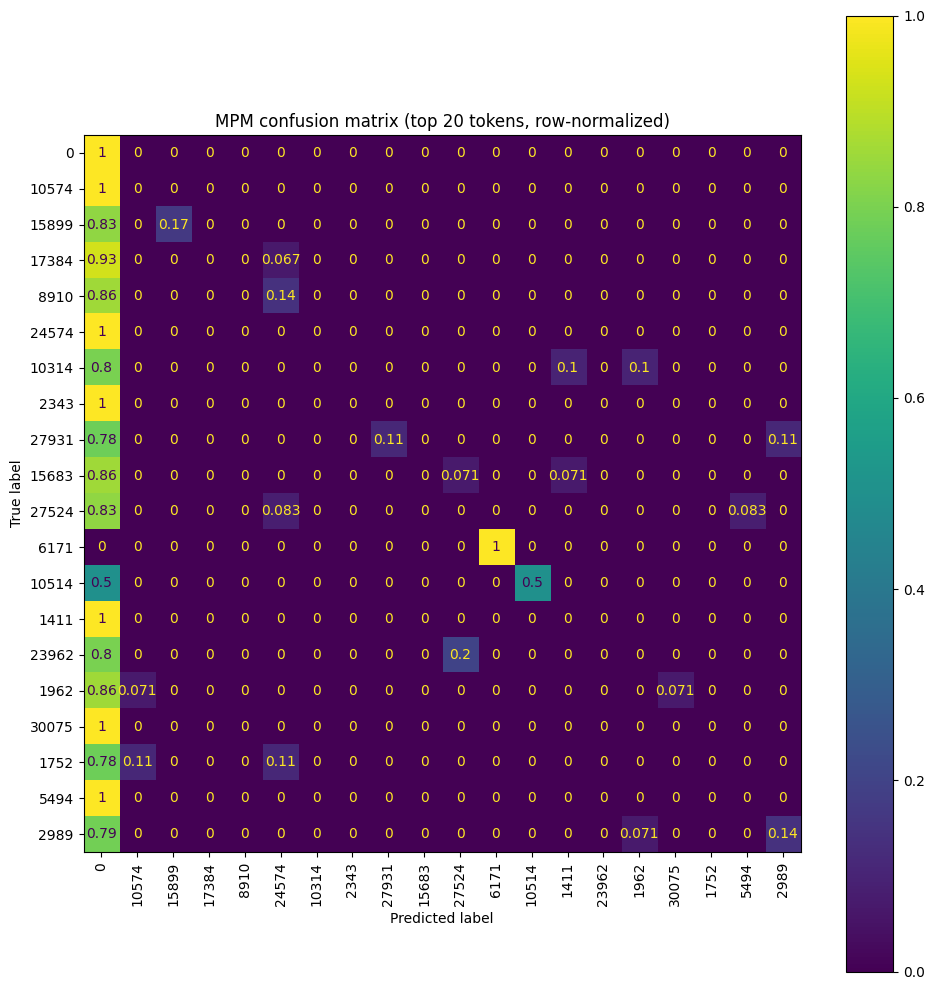

In [12]:
accuracy = (all_preds_masked == all_targets_masked).mean()
print(f"Overall MPM accuracy on masked positions: {accuracy:.4f}")

# limit the confusion matrix to the most frequent tokens for readability
top_k = 20
unique, counts = np.unique(all_targets_masked, return_counts=True)
top_tokens = unique[np.argsort(-counts)][:top_k]

mask_top = np.isin(all_targets_masked, top_tokens) & np.isin(all_preds_masked, top_tokens)
cm = confusion_matrix(
    all_targets_masked[mask_top],
    all_preds_masked[mask_top],
    labels=top_tokens,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_tokens).plot(
    ax=ax, xticks_rotation=90, colorbar=True, cmap="viridis"
)
ax.set_title(f"MPM confusion matrix (top {top_k} tokens, row-normalized)")
plt.tight_layout()
plt.show()

### 9b. Is the model collapsing to predicting the start token?

Position 0 is *always* the trivial start token (true label `0`), and since every jet
contributes exactly one position-0 sample, token `0` is guaranteed to be the single most
frequent true class in the pooled data above — that alone would make row/column `0` stand out
in the confusion matrix without indicating a problem.

The more concerning signal is that *other* true tokens (rows other than `0`) also show large
mass in the predicted-`0` column. To check if this is a real collapse (not just the position-0
artifact), redo the pooled accuracy/prediction-distribution check with position 0 excluded.


In [14]:
all_preds_masked_no0 = []
all_targets_masked_no0 = []

for preds, targets, mask in zip(
    test_mpm_pred_list, test_mpm_target_list, test_valid_particle_but_masked_mask_list
):
    mask_bool = mask.astype(bool).copy()
    mask_bool[:, 0] = False  # exclude the trivial start-token position
    all_preds_masked_no0.append(preds[mask_bool])
    all_targets_masked_no0.append(targets[mask_bool])

all_preds_masked_no0 = np.concatenate(all_preds_masked_no0)
all_targets_masked_no0 = np.concatenate(all_targets_masked_no0)

accuracy_no0 = (all_preds_masked_no0 == all_targets_masked_no0).mean()
frac_pred_is_start_token = (all_preds_masked_no0 == 0).mean()
frac_target_is_start_token = (all_targets_masked_no0 == 0).mean()

print("Excluding position 0 (the trivial start-token position):")
print(f"  n_samples:                                    {len(all_preds_masked_no0)}")
print(f"  accuracy:                                      {accuracy_no0:.4f}")
print(f"  fraction of predictions == token 0 (start tok): {frac_pred_is_start_token:.4f}")
print(f"  fraction of TRUE targets == token 0:            {frac_target_is_start_token:.4f}")

# most frequently predicted tokens, regardless of whether they're correct
pred_unique, pred_counts = np.unique(all_preds_masked_no0, return_counts=True)
top_predicted = pred_unique[np.argsort(-pred_counts)][:10]
top_predicted_frac = pred_counts[np.argsort(-pred_counts)][:10] / len(all_preds_masked_no0)

print("\nTop 10 most frequently *predicted* tokens (excl. position 0):")
for tok, frac in zip(top_predicted, top_predicted_frac):
    print(f"  token {tok:>6d}: {frac:.4f} of all predictions")


Excluding position 0 (the trivial start-token position):
  n_samples:                                    78378
  accuracy:                                      0.0189
  fraction of predictions == token 0 (start tok): 0.1710
  fraction of TRUE targets == token 0:            0.0000

Top 10 most frequently *predicted* tokens (excl. position 0):
  token      0: 0.1710 of all predictions
  token  25945: 0.0020 of all predictions
  token   6171: 0.0016 of all predictions
  token  16338: 0.0015 of all predictions
  token   8618: 0.0013 of all predictions
  token  31825: 0.0013 of all predictions
  token   9853: 0.0013 of all predictions
  token   8718: 0.0012 of all predictions
  token   9766: 0.0011 of all predictions
  token   3523: 0.0011 of all predictions


## 10. Visualize Sample Predictions vs Ground Truth

Pick a single example (jet) from the last collected batch and plot its sequence of predicted
vs. true tokens at the masked positions.

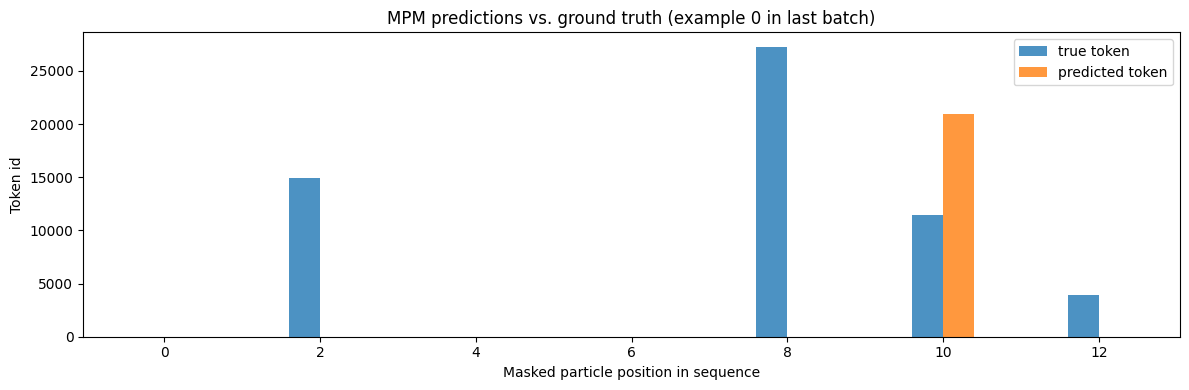

Correct: 1 / 5 masked positions (20.00%)


In [19]:
example_idx = 0  # index within the last collected batch

preds = test_mpm_pred_list[-1][example_idx]
targets = test_mpm_target_list[-1][example_idx]
mask = test_valid_particle_but_masked_mask_list[-1][example_idx].astype(bool)

positions = np.arange(len(preds))[mask]
preds_masked = preds[mask]
targets_masked = targets[mask]

fig, ax = plt.subplots(figsize=(12, 4))
width = 0.4
ax.bar(positions - width / 2, targets_masked, width=width, label="true token", alpha=0.8)
ax.bar(positions + width / 2, preds_masked, width=width, label="predicted token", alpha=0.8)
ax.set_xlabel("Masked particle position in sequence")
ax.set_ylabel("Token id")
ax.set_title(f"MPM predictions vs. ground truth (example {example_idx} in last batch)")
ax.legend()
plt.tight_layout()
plt.show()

match = (preds_masked == targets_masked)
print(f"Correct: {match.sum()} / {len(match)} masked positions ({match.mean():.2%})")

In [ ]:
import torch.nn.functional as F

# diagnose *how* the model collapses to token 0: is it confidently wrong (softmax mass
# concentrated on id 0), or just an argmax artifact on an otherwise near-uniform distribution?
# NOTE: use model_step_output directly, not the `mask`/`logits_mpm` names above, since those
# have been overwritten (reassigned to numpy arrays) by the loops in earlier cells.
logits_mpm = model_step_output["logits_mpm"]
targets_mpm = model_step_output["targets_mpm"]
mask_no0 = model_step_output["valid_particle_but_masked_mask"].clone()
mask_no0[:, 0] = 0
mask_no0_bool = mask_no0.bool()

probs_mpm = F.softmax(logits_mpm, dim=-1)  # (B, T, vocab)

prob_token0 = probs_mpm[..., 0][mask_no0_bool]
max_prob = probs_mpm.max(dim=-1).values[mask_no0_bool]
true_token_prob = probs_mpm.gather(-1, targets_mpm.unsqueeze(-1)).squeeze(-1)[mask_no0_bool]
argmax_is_0 = (torch.argmax(logits_mpm, dim=-1) == 0) & mask_no0_bool

vocab_size = logits_mpm.shape[-1]
print(f"vocab size: {vocab_size}  (uniform-chance prob per class: {1 / vocab_size:.2e})")
print(f"n masked samples (excl. pos 0): {mask_no0_bool.sum().item()}")
print(f"fraction where argmax == token 0:        {argmax_is_0.float().mean().item():.4f}")
print(f"mean softmax prob assigned to token 0:    {prob_token0.mean().item():.4f}")
print(f"mean softmax prob assigned to true token: {true_token_prob.mean().item():.4f}")
print(f"mean top-1 (max) softmax prob overall:    {max_prob.mean().item():.4f}")
print()
print("mean softmax prob assigned to token 0, split by whether argmax == 0:")
argmax_is_0_flat = argmax_is_0[mask_no0_bool]
print(f"  when argmax == 0:     {prob_token0[argmax_is_0_flat].mean().item():.4f}")
print(f"  when argmax != 0:     {prob_token0[~argmax_is_0_flat].mean().item():.4f}")


vocab size: 32770  (uniform-chance prob per class: 3.05e-05)
n masked samples (excl. pos 0): 3702
fraction where argmax == token 0:        0.0265
mean softmax prob assigned to token 0:    0.0211
mean softmax prob assigned to true token: 0.0043
mean top-1 (max) softmax prob overall:    0.0389

mean softmax prob assigned to token 0, split by whether argmax == 0:


IndexError: too many indices for tensor of dimension 1

## 11. Compare `test_loss_mpm` / accuracy Across Checkpoints

Load every saved checkpoint in the run directory (in epoch order) and evaluate MPM loss/accuracy
on the *same* fixed set of test batches, to see whether MPM performance is still improving or has
plateaued.

This can be slow (reloads the model + reruns forward passes per checkpoint) — reduce
`N_EVAL_BATCHES` if needed.

In [16]:
import re
from pathlib import Path

CHECKPOINT_DIR = Path(CKPT_PATH).parent
N_EVAL_BATCHES = 5  # number of fixed batches to evaluate each checkpoint on

# collect "epoch_XXX_step_YYY_loss_ZZZ.ckpt" checkpoints (skip best.ckpt / last.ckpt, no epoch info)
ckpt_paths = sorted(
    CHECKPOINT_DIR.glob("epoch_*.ckpt"),
    key=lambda p: int(re.search(r"epoch_(\d+)_", p.name).group(1)),
)
print(f"Found {len(ckpt_paths)} epoch checkpoints in {CHECKPOINT_DIR}")
for p in ckpt_paths:
    print(f"  {p.name}")

Found 5 epoch checkpoints in /home/users/w/wozniak/dev/enhancing-ntp4jets/trained/omnijet-backbone-multihead-allfeat-mpm/runs/2026-08-17_11-46-48_gpu050_RetentiveUnuntrium/checkpoints
  epoch_005_step_600000_loss_1.10362.ckpt
  epoch_007_step_800000_loss_1.10362.ckpt
  epoch_009_step_1000000_loss_1.09900.ckpt
  epoch_011_step_1200000_loss_1.09900.ckpt
  epoch_013_step_1400000_loss_1.09900.ckpt


In [17]:
import gc

# free the original `model` from GPU memory first — otherwise it sits alongside each
# freshly-loaded `ckpt_model` below and doubles the VRAM footprint, causing OOM
model = model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

# the dataloader's batch size (e.g. 500) is too large to run a forward pass on for every
# checkpoint without OOM-ing, so instead of shrinking N_EVAL_BATCHES, split each fixed batch
# into smaller sub-batches and evaluate those sequentially, accumulating a sample-weighted
# average — this keeps every collected sample without needing all of it on the GPU at once.
EVAL_SUB_BATCH_SIZE = 32

# pre-fetch a fixed set of batches once (kept on CPU), so every checkpoint is evaluated on
# identical data
fixed_batches = []
_iter = iter(datamodule.test_dataloader())
for _ in range(N_EVAL_BATCHES):
    b = next(_iter)
    b = {k: (v.cpu() if torch.is_tensor(v) else v) for k, v in b.items()}
    fixed_batches.append(b)


def iter_sub_batches(batch, sub_batch_size):
    """Yield successive sub-batches of a batch dict, moved to `device`."""
    n = next(v.shape[0] for v in batch.values() if torch.is_tensor(v))
    for start in range(0, n, sub_batch_size):
        stop = start + sub_batch_size
        yield {
            k: (v[start:stop].to(device) if torch.is_tensor(v) else v) for k, v in batch.items()
        }, stop - start if stop <= n else n - start


results = []
for ckpt_path in ckpt_paths:
    epoch = int(re.search(r"epoch_(\d+)_", ckpt_path.name).group(1))
    ckpt_model = BackboneMultiHeadLightning.load_from_checkpoint(str(ckpt_path), map_location=device)
    ckpt_model = ckpt_model.to(device).eval()

    total_samples = 0
    weighted_loss_sum = 0.0
    weighted_acc_sum = 0.0
    with torch.no_grad():
        for b in fixed_batches:
            for sub_batch, n_samples in iter_sub_batches(b, EVAL_SUB_BATCH_SIZE):
                out = ckpt_model.model_step(sub_batch)
                weighted_loss_sum += out["loss_mpm"].item() * n_samples
                weighted_acc_sum += out["acc_dict_mpm"]["acc_all_tokens"].item() * n_samples
                total_samples += n_samples
                del out, sub_batch

    results.append(
        {
            "epoch": epoch,
            "ckpt": ckpt_path.name,
            "loss_mpm": weighted_loss_sum / total_samples,
            "acc_all_tokens": weighted_acc_sum / total_samples,
        }
    )
    print(f"epoch {epoch:>4d}: loss_mpm={results[-1]['loss_mpm']:.4f}  acc_all_tokens={results[-1]['acc_all_tokens']:.4f}")

    ckpt_model = ckpt_model.to("cpu")
    del ckpt_model
    gc.collect()
    torch.cuda.empty_cache()

# restore the original model back onto the GPU for any later cells that still use it
model = model.to(device)

You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with clip_min_input_space = 0 and clip_max_input_space = None. Make sure this is intended. THIS IS NOT INVERTIBLE.
You are clipping the values of the feature 'part_mass' in input space with 

epoch    5: loss_mpm=1.0831  acc_all_tokens=0.0413


NOT applying causal mask in the attention blocks. If you are using this model for an autoregressive generative task, this is probably not what you want.


epoch    7: loss_mpm=1.0775  acc_all_tokens=0.0422


NOT applying causal mask in the attention blocks. If you are using this model for an autoregressive generative task, this is probably not what you want.


epoch    9: loss_mpm=1.0729  acc_all_tokens=0.0437


NOT applying causal mask in the attention blocks. If you are using this model for an autoregressive generative task, this is probably not what you want.


epoch   11: loss_mpm=1.0759  acc_all_tokens=0.0430


NOT applying causal mask in the attention blocks. If you are using this model for an autoregressive generative task, this is probably not what you want.


epoch   13: loss_mpm=1.0767  acc_all_tokens=0.0418


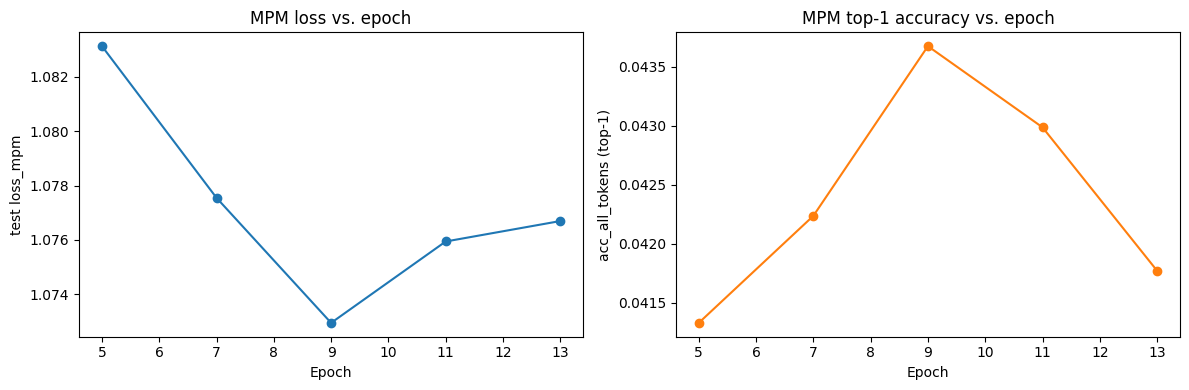

In [18]:
epochs = [r["epoch"] for r in results]
losses = [r["loss_mpm"] for r in results]
accs = [r["acc_all_tokens"] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, losses, marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("test loss_mpm")
ax1.set_title("MPM loss vs. epoch")

ax2.plot(epochs, accs, marker="o", color="tab:orange")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("acc_all_tokens (top-1)")
ax2.set_title("MPM top-1 accuracy vs. epoch")

plt.tight_layout()
plt.show()